# IPL Match Data Analysis (Exploratory Data Analysis)

**Tools Used:** Python, Pandas, Matplotlib, Seaborn

## 1. Introduction

This project performs an exploratory data analysis (EDA) on the IPL matches dataset to uncover patterns and insights related to team performance, toss decisions, and match outcomes.

The analysis focuses on the following key areas:

- Team win percentages and overall performance  
- Impact of toss results on match outcomes  
- Season-wise distribution of IPL matches  
- Success rate of different toss decisions (bat vs field)

In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


## 2. Data Loading

In [ ]:
ipl=pd.read_csv("matches.csv")

In [106]:
#Total Number of rows and columns
ipl.shape

(756, 18)

## 3. Data Cleaning

In [107]:
#Delete duplicate Values
print("Duplicate rows:", ipl.duplicated().sum())
ipl = ipl.drop_duplicates()
print("Rows after removing duplicates:", len(ipl))

Duplicate rows: 0
Rows after removing duplicates: 756


In [108]:
# Missing Value Check
ipl.isnull().sum()

id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               4
win_by_runs          0
win_by_wickets       0
player_of_match      4
venue                0
umpire1              2
umpire2              2
umpire3            637
dtype: int64

In [109]:
# Detailed info of data types of all columns including non-null counts
ipl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               756 non-null    int64 
 1   season           756 non-null    int64 
 2   city             749 non-null    object
 3   date             756 non-null    object
 4   team1            756 non-null    object
 5   team2            756 non-null    object
 6   toss_winner      756 non-null    object
 7   toss_decision    756 non-null    object
 8   result           756 non-null    object
 9   dl_applied       756 non-null    int64 
 10  winner           752 non-null    object
 11  win_by_runs      756 non-null    int64 
 12  win_by_wickets   756 non-null    int64 
 13  player_of_match  752 non-null    object
 14  venue            756 non-null    object
 15  umpire1          754 non-null    object
 16  umpire2          754 non-null    object
 17  umpire3          119 non-null    ob

In [110]:
#Columns names
column_names=ipl.columns.tolist()
for i in column_names:
    print(i)

id
season
city
date
team1
team2
toss_winner
toss_decision
result
dl_applied
winner
win_by_runs
win_by_wickets
player_of_match
venue
umpire1
umpire2
umpire3


## 4. Exploratory Data Analysis

In [111]:
# --- Get all team names ---
pd.unique(ipl[['team1','team2']].values.ravel())

array(['Sunrisers Hyderabad', 'Royal Challengers Bangalore',
       'Mumbai Indians', 'Rising Pune Supergiant', 'Gujarat Lions',
       'Kolkata Knight Riders', 'Kings XI Punjab', 'Delhi Daredevils',
       'Chennai Super Kings', 'Rajasthan Royals', 'Deccan Chargers',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Rising Pune Supergiants',
       'Delhi Capitals'], dtype=object)

In [112]:
# Count how many times each player has won the Player of the Match award
player_of_match_counts = ipl['player_of_match'].value_counts()
print(player_of_match_counts)

player_of_match
CH Gayle          21
AB de Villiers    20
MS Dhoni          17
RG Sharma         17
DA Warner         17
                  ..
Imran Tahir        1
K Paul             1
K Ahmed            1
S Gill             1
S Hetmyer          1
Name: count, Length: 226, dtype: int64


In [113]:
print("-" * 30)
print("IPL DATASET SUMMARY")
print("-" * 30)
seasons = sorted(ipl['season'].unique())
print(f"Years Covered  : {seasons[0]} to {seasons[-1]}")
print(f"List of Seasons: {', '.join(map(str, seasons))}")
print(f"Total Seasons  : {len(seasons)}")
print("-" * 30)

------------------------------
IPL DATASET SUMMARY
------------------------------
Years Covered  : 2008 to 2019
List of Seasons: 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019
Total Seasons  : 12
------------------------------


##  Team Performance Analysis

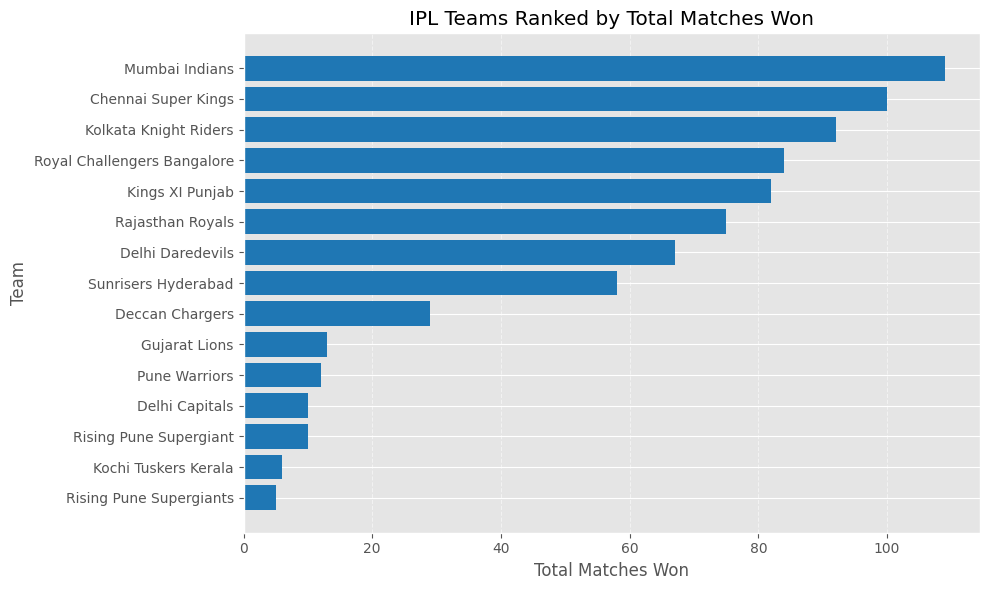

In [114]:
#Top Winning Teams
matches_played = ipl['team1'].value_counts() + ipl['team2'].value_counts()
matches_won = ipl['winner'].value_counts()
team_stats = pd.DataFrame({
    'Matches_Played': matches_played,
    'Matches_Won': matches_won
}).fillna(0)
team_stats['Win_%'] = (team_stats['Matches_Won'] / team_stats['Matches_Played'] * 100).round(2)
team_stats = team_stats.sort_values(by='Matches_Won', ascending=True)
plt.figure(figsize=(10,6))
plt.barh(team_stats.index,
         team_stats['Matches_Won'],
         color='#1f77b4')
plt.xlabel("Total Matches Won")
plt.ylabel("Team")
plt.title("IPL Teams Ranked by Total Matches Won")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Teams such as Mumbai Indians and Chennai Super Kings show consistently higher win percentages, indicating stronger long-term performance across IPL seasons.

##  Venue Analysis

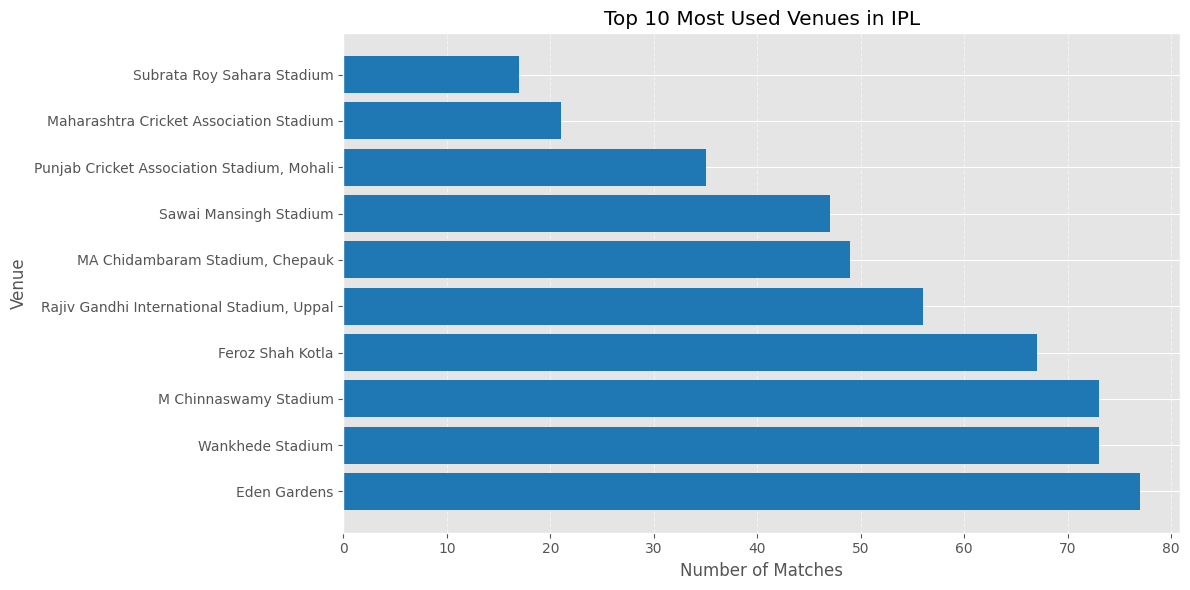

In [115]:
#                            -----------Most Successful Venues-----------
# This analysis identifies the stadiums that have hosted the most IPL matches.
venue_matches = ipl['venue'].value_counts().head(10)
plt.figure(figsize=(12,6))
plt.barh(venue_matches.index,
         venue_matches.values,
         color="#1f77b4")
plt.xlabel("Number of Matches")
plt.ylabel("Venue")
plt.title("Top 10 Most Used Venues in IPL")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Insight
Certain venues host a significantly higher number of matches, reflecting their importance as major IPL hosting stadiums.

##  Player Performance

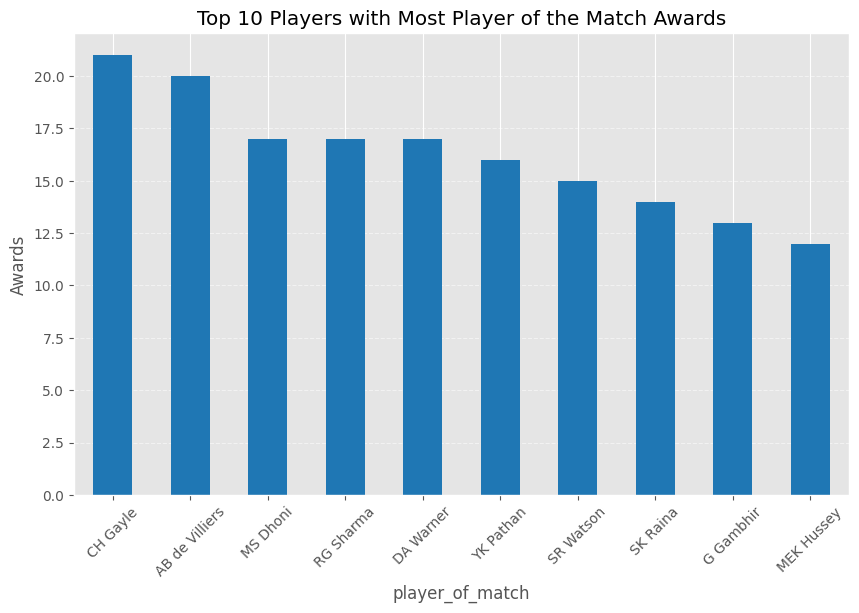

In [116]:
# Player of the Match Leaders
top_players = ipl['player_of_match'].value_counts().head(10)
plt.figure(figsize=(10,6))
top_players.plot(kind='bar', color="#1f77b4")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.title("Top 10 Players with Most Player of the Match Awards")
plt.ylabel("Awards")
plt.show()

Certain players dominate the Player of the Match awards, highlighting their consistent match-winning performances.

##  Toss Impact Analysis

In [117]:
toss_match_win = (ipl['toss_winner'] == ipl['winner']).sum()
total_matches = len(ipl)
percentage = (toss_match_win / total_matches) * 100
print("Toss winner also won the match:", round(percentage,2), "% of the time")

Toss winner also won the match: 51.98 % of the time


## Insight:
The toss winner also wins the match in a significant percentage of games, suggesting that the toss can influence match outcomes.

### Total Toss Decision

In [118]:
toss_counts = ipl['toss_decision'].value_counts()
print(f"Total Tosses : {toss_counts.sum()}")
print("-" * 25)
for decision, count in toss_counts.items():
    percentage = (count / toss_counts.sum()) * 100
    print(f"{decision.capitalize():<10} : {count} times ({percentage:.1f}%)")

Total Tosses : 756
-------------------------
Field      : 463 times (61.2%)
Bat        : 293 times (38.8%)


## --- Match Analysis ---

In [ ]:
winner_count = ipl['winner'].value_counts()
total_matches_played = ipl['team1'].value_counts() + ipl['team2'].value_counts()
winner_count = winner_count.reindex(total_matches_played.index, fill_value=0)
winning_percentage = (winner_count / total_matches_played) * 100
winning_percentage = winning_percentage.round(2)  # round to 2 decimals
analysis = pd.DataFrame({
    'Team': total_matches_played.index,
    'Matches Played': total_matches_played.values,
    'Matches Won': winner_count.values,
    'Winning %': winning_percentage.values})
analysis = analysis.sort_values(by='Winning %', ascending=False).reset_index(drop=True)
analysis

,Team,Matches Played,Matches Won,Winning %
0,Delhi Capitals,16,10,62.50
1,Rising Pune Supergiant,16,10,62.50
2,Chennai Super Kings,164,100,60.98
3,Mumbai Indians,187,109,58.29
4,Sunrisers Hyderabad,108,58,53.70
5,Kolkata Knight Riders,178,92,51.69
6,Rajasthan Royals,147,75,51.02
7,Royal Challengers Bangalore,180,84,46.67
8,Kings XI Punjab,176,82,46.59
9,Gujarat Lions,30,13,43.33


## Matches Played vs Winning % (Dual Axis Chart) 

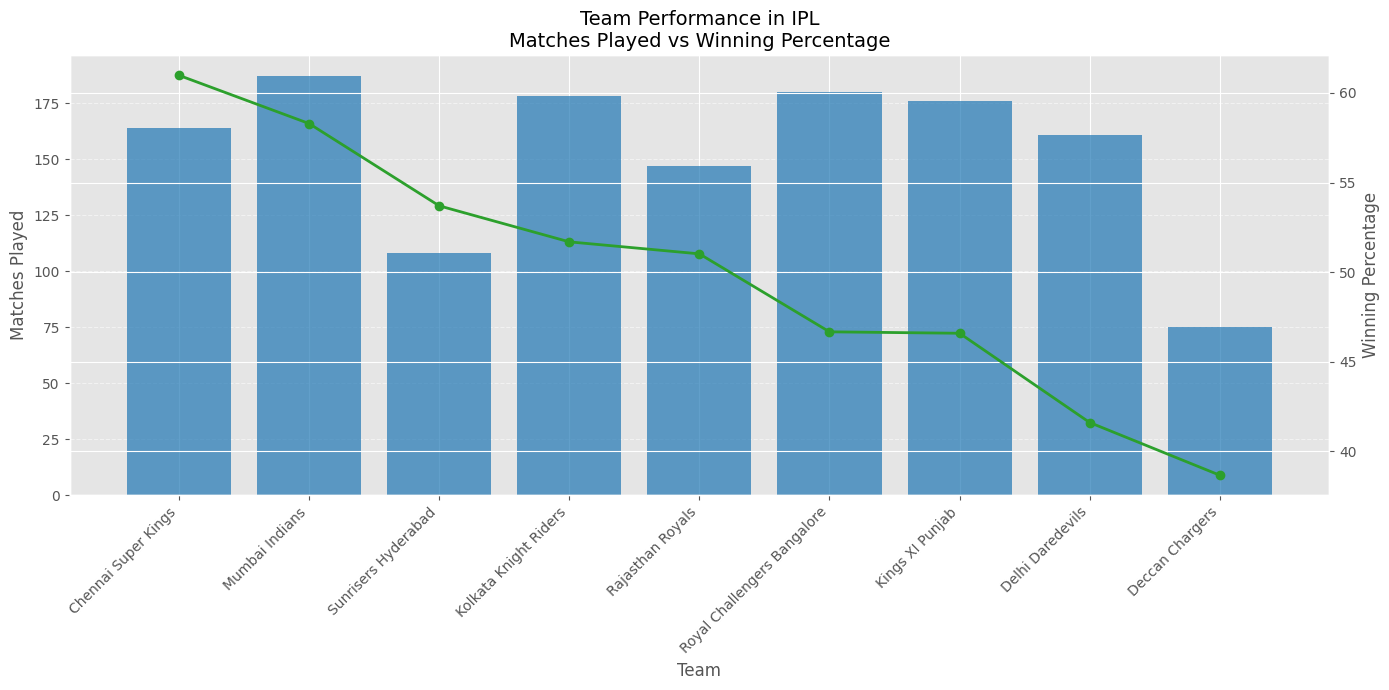

In [ ]:
# Filter teams with more than 50 matches
Filtered_Teams = analysis[analysis['Matches Played'] > 50]
Filtered_Teams = Filtered_Teams.sort_values(by='Winning %', ascending=False)
teams = Filtered_Teams['Team']
matches_played = Filtered_Teams['Matches Played']
winning_percentage = Filtered_Teams['Winning %']
fig, ax1 = plt.subplots(figsize=(14,7))
plt.title("Team Performance in IPL\nMatches Played vs Winning Percentage", fontsize=14)
ax1.bar(teams, matches_played,
        color='#1f77b4',
        alpha=0.7,
        label='Matches Played')
ax1.set_xlabel("Team")
ax1.set_ylabel("Matches Played")
plt.xticks(rotation=45, ha='right')
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax2 = ax1.twinx()
ax2.plot(teams, winning_percentage,
         color='#2ca02c',
         marker='o',
         linewidth=2,
         label='Winning %')
ax2.set_ylabel("Winning Percentage")
plt.tight_layout()
plt.show()

## Win Rate Ranking Chart 

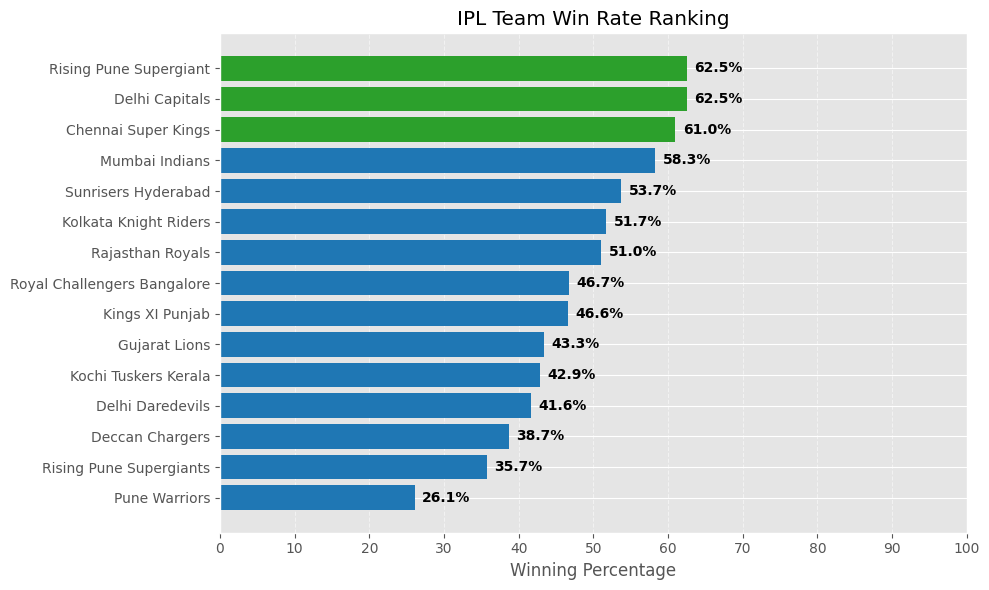

In [123]:
fig, ax = plt.subplots(figsize=(10,6))
Winning_rate = analysis.sort_values(by="Winning %", ascending=True)
x = Winning_rate['Winning %']
y = Winning_rate['Team']
top_teams = Winning_rate.nlargest(3, 'Winning %')['Team']
colors = ['#2ca02c' if team in top_teams.values else '#1f77b4' for team in y]
bars=ax.barh(y, x, color=colors)
plt.xticks(range(0, 101, 10))
for bar in bars:
    width = bar.get_width()
    ax.text(width + 1,  
            bar.get_y() + bar.get_height()/2, 
            f'{width:.1f}%', va='center', fontweight='bold')
ax.set_xlabel("Winning Percentage")
ax.set_title("IPL Team Win Rate Ranking")
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()  

### Insight
Teams with higher winning percentages demonstrate greater consistency and competitive strength across seasons in the Indian Premier League. A small group of teams clearly outperform others, indicating long-term dominance and better match performance.

 ## IPL Matches Per Seasons 

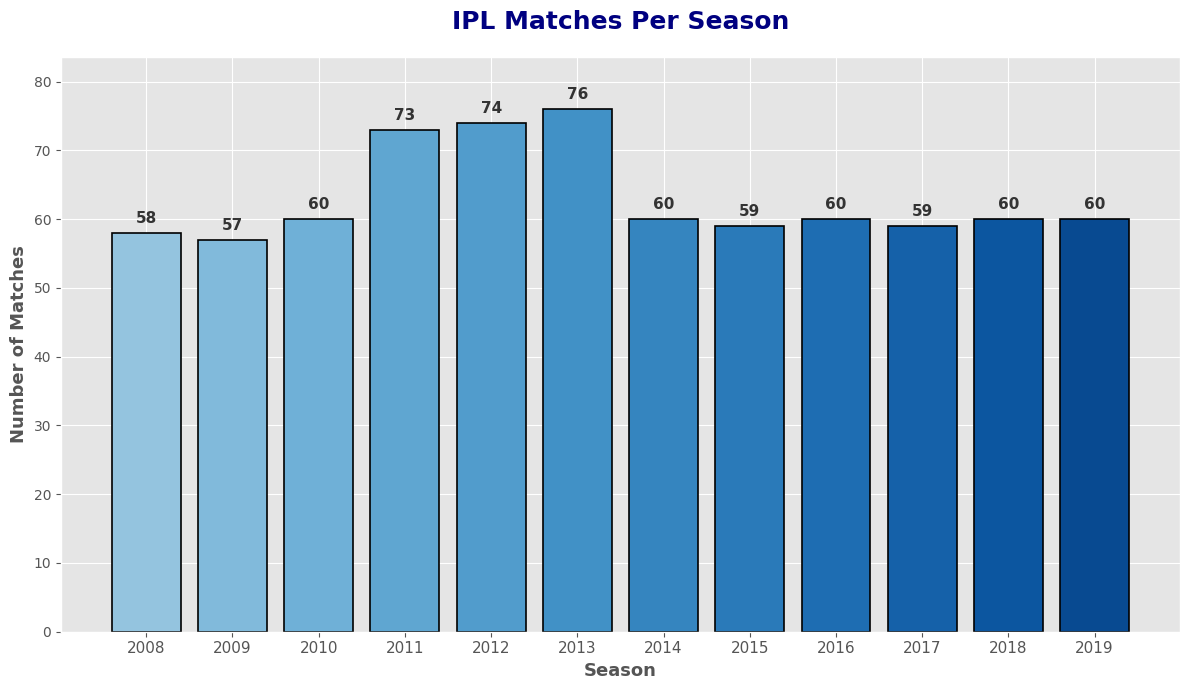

In [ ]:
matches_per_season = ipl['season'].value_counts().sort_index()
x = matches_per_season.index
y = matches_per_season.values
plt.figure(figsize=(12, 7))
plt.style.use('ggplot') 
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(x)))
bars = plt.bar(x, y, color=colors, edgecolor='black', linewidth=1.2)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, 
             height + 1,         
             str(int(height)),  
             ha='center', 
             va='bottom', 
             fontsize=11, 
             fontweight='bold', 
             color='#333333')
plt.xlabel("Season", fontsize=13, fontweight='bold')
plt.ylabel("Number of Matches", fontsize=13, fontweight='bold')
plt.title("IPL Matches Per Season", fontsize=18, fontweight='bold', color='#000080', pad=20)
plt.xticks(x, rotation=0, fontsize=11)
plt.ylim(0, max(y) * 1.1)
plt.tight_layout()
plt.show()

### Insight
The number of matches per season has generally increased over time, reflecting the expansion and growing popularity of the Indian Premier League. Changes in match counts are mainly due to variations in the number of participating teams and tournament formats.

## Impact of Toss Decisions on Match Outcomes: A Team-wise Conversion Analysis

In [ ]:
toss_win = ipl['toss_winner'].value_counts()
match_win = ipl['winner'].value_counts()
toss_and_match_win = ipl[ipl['toss_winner'] == ipl['winner']]['winner'].value_counts()
total_matches = ipl['team1'].value_counts() + ipl['team2'].value_counts()
df = pd.DataFrame({
    'Total_Played': total_matches,
    'Toss_Win': toss_win,
    'Match_Win': match_win,
    'Toss_and_Match_Win': toss_and_match_win}).fillna(0).astype(int)
df['Toss_Win_Match_Win_%'] = (df['Toss_and_Match_Win'] / df['Toss_Win'] * 100).round(2)
df['Overall_Win_%'] = (df['Match_Win'] / df['Total_Played'] * 100).round(2)
df['Toss_Advantage'] = (df['Toss_Win_Match_Win_%'] - df['Overall_Win_%']).round(2)
df = df.sort_values(by='Toss_Advantage', ascending=False)
display(df.style.background_gradient(cmap='RdYlGn', subset=['Toss_Advantage']))

,Total_Played,Toss_Win,Match_Win,Toss_and_Match_Win,Toss_Win_Match_Win_%,Overall_Win_%,Toss_Advantage
Gujarat Lions,30,15,13,10,66.670000,43.330000,23.340000
Rising Pune Supergiant,16,6,10,5,83.330000,62.500000,20.830000
Delhi Capitals,16,10,10,7,70.000000,62.500000,7.500000
Rising Pune Supergiants,14,7,5,3,42.860000,35.710000,7.150000
Kochi Tuskers Kerala,14,8,6,4,50.000000,42.860000,7.140000
Kolkata Knight Riders,178,92,92,53,57.610000,51.690000,5.920000
Deccan Chargers,75,43,29,19,44.190000,38.670000,5.520000
Royal Challengers Bangalore,180,81,84,41,50.620000,46.670000,3.950000
Chennai Super Kings,164,89,100,57,64.040000,60.980000,3.060000
Delhi Daredevils,161,80,67,35,43.750000,41.610000,2.140000


### Insight
This analysis compares a team's overall winning percentage with the percentage of matches won after winning the toss in the Indian Premier League. The results show that while winning the toss can provide a slight advantage for some teams, it does not consistently guarantee match victory. This suggests that team performance and match strategy play a more important role than the toss outcome.

## Toss Decision Analysis 

In [ ]:

total_decisions = ipl['toss_decision'].value_counts()
toss_winner_wins = ipl[ipl['toss_winner'] == ipl['winner']]
wins_after_decision = toss_winner_wins['toss_decision'].value_counts()
decision_analysis = pd.DataFrame({
    'Total_Decisions': total_decisions,
    'Wins_After_Decision': wins_after_decision
}).fillna(0).astype(int)
decision_analysis['Success_Rate_%'] = (
    decision_analysis['Wins_After_Decision'] /
    decision_analysis['Total_Decisions'] * 100).round(2)
decision_analysis

,Total_Decisions,Wins_After_Decision,Success_Rate_%
toss_decision,,,
field,463,259,55.94
bat,293,134,45.73


### Insight

Teams choosing to field after winning the toss tend to have a higher success rate 
compared to teams choosing to bat first.
This suggests that chasing targets may 
provide a strategic advantage in many IPL matches.

## Correlation Heatmap of IPL Dataset

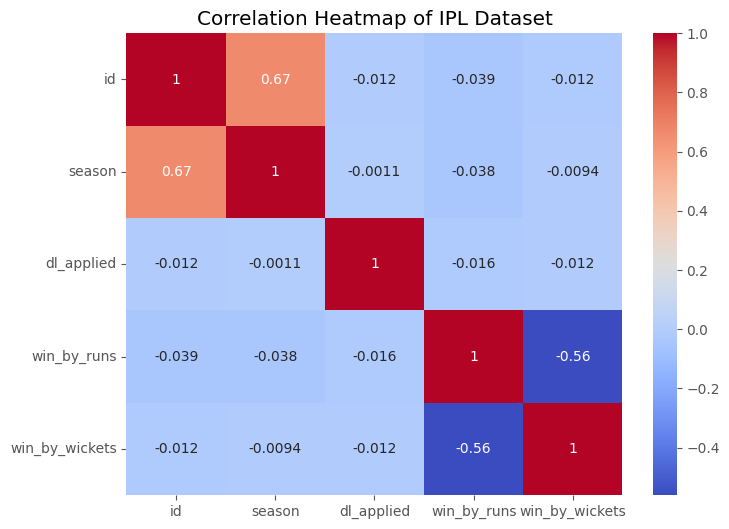

In [125]:
numeric_data = ipl.select_dtypes(include=['int64','float64'])
corr_matrix = numeric_data.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of IPL Dataset")
plt.show()

### Insight
The correlation heatmap shows that most numerical variables in the dataset have weak correlations with each other. This indicates that match outcomes are influenced by multiple independent factors rather than a single dominant variable.

## Key Insights

• Teams that win the toss often gain a strategic advantage.  
• Fielding after winning the toss shows a higher success rate in many matches.  
• Some teams maintain consistently higher win percentages across seasons.  
• Player of the Match awards highlight consistent individual performers.

## 9. Conclusion

This exploratory data analysis of the IPL matches dataset revealed several useful insights into match outcomes and team strategies.

The analysis showed that team performance varies significantly across seasons, with some teams maintaining consistently higher win percentages than others. Toss decisions also play an important role in match outcomes, as teams choosing to field after winning the toss often demonstrate a higher success rate, suggesting that chasing targets may provide a strategic advantage in many matches.

Additionally, the study highlighted patterns in match distribution across seasons and identified players who frequently earned the "Player of the Match" award, indicating consistent individual performance.

Overall, this analysis demonstrates how exploratory data analysis can help uncover meaningful patterns in sports data and provide insights into team strategies, player performance, and match dynamics within the IPL.